In [2]:
from dotenv import load_dotenv
import os

load_dotenv()

os.environ["LANGCHAIN_PROJECT"] = "notebook-1_tool_in_langgr"
os.environ["LANGCHAIN_TRACING_V2"] = "true"

In [3]:
# ================= TYPES =================
from typing import TypedDict, Literal, Annotated

# ================= LANGCHAIN CORE =================
from langchain_core.documents import Document
from langchain_core.prompts import PromptTemplate
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, BaseMessage, HumanMessage

# ================= MODELS =================
from langchain_openai import ChatOpenAI, OpenAI
from langchain_huggingface import HuggingFaceEmbeddings

# ================= VECTOR STORES =================
from langchain_community.vectorstores import FAISS
from langchain_chroma import Chroma

# ================= UTILITIES =================
from youtube_transcript_api import YouTubeTranscriptApi
from langchain_text_splitters import RecursiveCharacterTextSplitter

# ================= LANGGRAPH =================
from langgraph.graph import StateGraph, START, END

D:\code floders\PYTHON-5\LANGCHAIN_MODELS\new_environment\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# from dotenv import load_dotenv, find_dotenv

# load_dotenv(find_dotenv())
# import os

# print(os.getenv("LANGCHAIN_TRACING_V2"))
# print(os.getenv("LANGCHAIN_PROJECT"))

In [5]:
os.environ["OPENROUTER_API_KEY"]="sk-or-v1-8015337cd089e7b362573bc14e0a12f5463a727ccbde806"



In [6]:
model = ChatOpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    model="openrouter/free",
    temperature=0.7,
)

In [7]:
import requests
from langchain.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun

# tools
search_tool = DuckDuckGoSearchRun(region="us-en")

@tool
def calculator(first_num: float, second_num: float, operation: str) -> dict:
    """
    Perform arithmetic operation.
            
    IMPORTANT:
    - operation MUST be one of: "add", "sub", "mul", "div"
    - Do NOT repeat or combine values (e.g., not "mulmul")
    """
    try:
        if operation == "add":
            result = first_num + second_num

        elif operation == "sub":
            result = first_num - second_num

        elif operation == "mul":
            result = first_num * second_num

        elif operation == "div":
            if second_num == 0:
                return {"error": "division by zero is not allowed"}
            result = first_num / second_num

        else:
            return {"error": f"unsupported operation '{operation}'"}

        return {
            "first_num": first_num,
            "second_num": second_num,
            "operation": operation,
            "result": result
        }

    except Exception as e:
        return {"error": str(e)}


@tool
def get_stock_price(symbol: str) -> dict:
    """
    fetch latest stock price for a given symbol (e.g. "AAPL","TSLA")
    using alpha vantage API
    """
    try:
        url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=MWK2YPU374TUK5RI"
        r = requests.get(url)
        r.raise_for_status()

        data = r.json()
        price = data.get("Global Quote", {}).get("05. price", "N/A")

        return {
            "symbol": symbol,
            "price": price
        }

    except Exception as e:
        return {"error": str(e)}

In [8]:
# make tool list 
tools =[get_stock_price, search_tool , calculator]

# make the llm tool-aware

llm_with_tools=model.bind_tools(tools)


In [9]:
from langgraph.graph.message import add_messages
# state

class ChatState(TypedDict):
    messages : Annotated[list[BaseMessage],add_messages]
    

In [10]:
# graph nodes
from langgraph.prebuilt import ToolNode
def chat_node(state:ChatState):

    """ LLM node that may answer or requesr a tool call"""
    messages = state['messages']
    response= llm_with_tools.invoke(messages)
    return {"messages":[response]}

tool_node = ToolNode(tools) # execute tool calls


In [11]:
# graph structure
graph=StateGraph(ChatState)
graph.add_node("chat_node",chat_node)
graph.add_node("tools",tool_node)

In [12]:
from langgraph.prebuilt import tools_condition
graph.add_edge(START , "chat_node")

# if the llm asked for a tool go to toolnode : else finish

graph.add_conditional_edges("chat_node",tools_condition)

graph.add_edge("tools","chat_node")


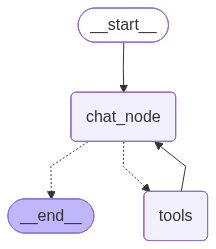

In [13]:
chatbot=graph.compile()
chatbot

In [14]:
out = chatbot.invoke({"messages": [HumanMessage(content="Hello !")]})

print(out)
print("******************")

print(out["messages"][-1].content)

{'messages': [HumanMessage(content='Hello !', additional_kwargs={}, response_metadata={}, id='edc1b7fe-2554-448d-ae3d-0cd612c3a418'), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 320, 'total_tokens': 330, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'cache_write_tokens': 0, 'video_tokens': 0}, 'cost': 0, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 0, 'upstream_inference_prompt_cost': 0, 'upstream_inference_completions_cost': 0}}, 'model_provider': 'openai', 'model_name': 'arcee-ai/trinity-large-preview:free', 'system_fingerprint': None, 'id': 'gen-1776506838-zLgVSzFzKTOtL2iSZveo', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019da00f-20c9-7f31-9b08-97919

In [15]:
out1 = chatbot.invoke({
    "messages": [HumanMessage(content="Use calculator tool to multiply 8 and 7")]
})

# print(out)
print("******************")

print(out1["messages"][-1].content)

******************
The product of 8 and 7 is **56**.


In [17]:
out1 = chatbot.invoke({
    "messages": [HumanMessage(content="what is the stock rate of apple")]
})

# print(out)
print("******************")

print(out1["messages"][-1].content)

******************
The current stock price for Apple (AAPL) is **$270.23**.
